# Análise de Propostas e Prestações de Contas - Presidência da República 2026

O presente projeto tem como objetivo realizar uma análise aprofundada com base nas propostas de governo oficiais e nas prestações de contas registradas no Tribunal Superior Eleitoral (TSE) para as **Eleições Presidenciais de 2026**.

Foram selecionados os planos de governo dos candidatos:
- Augusto Cury (AVANTE)
- Flavio Bolsonaro (PL)
- Lula (PT)
- Renan Santos (MISSÃO)
- Romeu Zema (NOVO)
- Ronaldo Caiado (PSD)

> **Estrutura de Visualização**: Cada candidato possui **células exclusivas e isoladas** para análise textual, eixos temáticos, temas críticos obrigatórios (*Privatização, Feminicídio, Minorias, Presídios, LGBTQIA+*), histórico de partidos e prestação de contas.


In [1]:
!pip install -q pypdf pdfplumber



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
import sys
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud, STOPWORDS
import pypdf

try:
    import pdfplumber
except ImportError:
    pdfplumber = None

# Configurações de estilo gráfico
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

# Download silencioso de recursos essenciais do NLTK
for res in ['punkt', 'stopwords', 'punkt_tab']:
    try:
        nltk.download(res, quiet=True)
    except Exception:
        pass

print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!


In [3]:
def resolve_filepath(filename, subfolder=""):
    """
    Localiza o arquivo de forma inteligente em qualquer ambiente (Colab / Local).
    Busca na raiz do Colab (/content), em subpastas ou no caminho local do projeto.
    """
    possiveis_caminhos = [
        Path('/content') / filename,
        Path('/content') / 'Arquivos' / subfolder / filename,
        Path('/content') / subfolder / filename,
        Path.cwd() / filename,
        Path.cwd() / 'Arquivos' / subfolder / filename,
        Path.cwd().parent / 'Arquivos' / subfolder / filename,
        Path(r'D:/Documents/Meus-Projetos/Análise-Eleições-2026/Arquivos') / subfolder / filename,
        Path(r'D:/Documents/Meus-Projetos/Análise-Eleições-2026') / filename
    ]
    for p in possiveis_caminhos:
        if p.exists():
            return p
            
    for base in [Path('/content'), Path.cwd(), Path(r'D:/Documents/Meus-Projetos/Análise-Eleições-2026')]:
        matches = list(base.glob(f"**/{filename}"))
        if matches:
            return matches[0]
            
    return Path(filename)


def resolve_csv(filename):
    """Localiza bases CSV na raiz do Colab (/content) ou na pasta de Dados_TSE."""
    possiveis_caminhos = [
        Path('/content') / filename,
        Path('/content') / 'Arquivos' / 'Dados_TSE' / filename,
        Path('/content') / 'Dados_TSE' / filename,
        Path.cwd() / filename,
        Path.cwd() / 'Arquivos' / 'Dados_TSE' / filename,
        Path.cwd().parent / 'Arquivos' / 'Dados_TSE' / filename,
        Path(r'D:/Documents/Meus-Projetos/Análise-Eleições-2026/Arquivos/Dados_TSE') / filename
    ]
    for p in possiveis_caminhos:
        if p.exists():
            return p
            
    for base in [Path('/content'), Path.cwd(), Path(r'D:/Documents/Meus-Projetos/Análise-Eleições-2026')]:
        matches = list(base.glob(f"**/{filename}"))
        if matches:
            return matches[0]
            
    return Path(filename)


In [4]:
def read_file_pdf(filepath):
    """Extrai texto completo de um arquivo PDF com fallback seguro."""
    filepath = Path(filepath)
    if not filepath.is_file():
        print(f"[AVISO] Arquivo não encontrado: {filepath.name}")
        return ""
    
    text = ""
    try:
        reader = pypdf.PdfReader(str(filepath))
        for page in reader.pages:
            t = page.extract_text()
            if t:
                text += t + "\n"
    except Exception:
        pass

    if not text.strip() and pdfplumber is not None:
        try:
            with pdfplumber.open(str(filepath)) as pdf:
                for page in pdf.pages:
                    t = page.extract_text()
                    if t:
                        text += t + "\n"
        except Exception:
            pass

    return text


def get_pdf_page_count(filepath):
    """Retorna o número total de páginas do arquivo PDF."""
    try:
        reader = pypdf.PdfReader(str(filepath))
        return len(reader.pages)
    except Exception:
        return 0


def extract_keywords(text, ignore_words=None, min_word_length=3):
    """Tokeniza e extrai palavras-chave filtrando stopwords e ruídos eleitorais."""
    if not text:
        return []
    
    tokens = word_tokenize(text)
    punctuations = ['(', ')', ';', ':', '[', ']', ',', '.', '--', '-', '#', '!', '*', '"', '%', '/', '\\', '?', '>', '<', '=', '+', '_', '{', '}', '@', '$', '§', '“', '”', '’']
    
    try:
        stop_words = set(stopwords.words('portuguese'))
    except Exception:
        stop_words = set()

    electoral_stopwords = {
        'governo', 'plano', 'proposta', 'propostas', 'candidato', 'candidatos',
        'programa', 'gestão', 'desenvolvimento', 'ação', 'ações', 'ano', 'anos',
        'cada', 'sobre', 'ainda', 'forma', 'todos', 'todas', 'país', 'estado',
        'município', 'nacional', 'público', 'pública', 'públicas', 'públicos',
        'social', 'sociais', 'novo', 'nova', 'novos', 'novas', 'projeto', 'projetos',
        'sistema', 'setor', 'área', 'áreas', 'população', 'pessoas', 'geral', 'bem',
        'assim', 'onde', 'além', 'através', 'fazer', 'garantir', 'promover', 'ampliar',
        'criar', 'fortalecer', 'melhorar', 'deve', 'devem', 'ser', 'ter', 'estar',
        'brasil', 'paraíba', 'brasileiro', 'brasileira', 'paraibano', 'paraibana'
    }
    
    all_stop = stop_words.union(electoral_stopwords)
    if ignore_words:
        all_stop.update([w.lower() for w in ignore_words])
    
    keywords = []
    for word in tokens:
        w_clean = word.strip()
        w_lower = w_clean.lower()
        if (w_clean not in punctuations and 
            w_lower not in all_stop and 
            len(w_clean) >= min_word_length):
            
            if w_clean.isdigit() or any(c.isdigit() for c in w_clean):
                continue
            keywords.append(w_lower)
            
    return keywords


def count_term_with_variations(text, keywords, target_topic):
    """Contabiliza ocorrências considerando sinônimos e termos compostos."""
    topic_clean = target_topic.lower().strip()
    text_lower = text.lower() if text else ""
    
    term_variants = {
        'privatização': ['privatização', 'privatizações', 'privatizar', 'desestatização', 'desestatizações'],
        'feminicídio': ['feminicídio', 'feminicídios', 'violência contra a mulher'],
        'minorias': ['minorias', 'minoria', 'grupos minoritários', 'populações vulneráveis'],
        'presídios': ['presídios', 'presídio', 'prisão', 'prisões', 'penitenciária', 'penitenciárias', 'sistema prisional', 'carcerário'],
        'lgbtqia+': ['lgbt', 'lgbtq', 'lgbtqia', 'lgbtqia+', 'lgbti', 'homofobia', 'transfobia', 'diversidade sexual']
    }
    
    variants = term_variants.get(topic_clean, [topic_clean])
    total_count = 0
    
    for v in variants:
        if " " in v or "+" in v:
            pattern = re.escape(v)
            matches = re.findall(pattern, text_lower)
            total_count += len(matches)
        else:
            total_count += keywords.count(v)
            
    return total_count


def create_word_cloud(keywords, candidate_name="Candidato"):
    """Gera nuvem de palavras profissional para o candidato."""
    if not keywords:
        print(f"[AVISO] Sem palavras-chave para {candidate_name}.")
        return
    
    word_freq = Counter(keywords)
    wc = WordCloud(background_color='white', max_words=90, colormap='Dark2',
                   stopwords=STOPWORDS, max_font_size=240,
                   random_state=42, width=2200, height=1100).generate_from_frequencies(word_freq)
    
    plt.figure(figsize=(12, 5.5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f'Nuvem de Palavras - {candidate_name}', fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_subjects_count(keywords, text, subjects, color='darkcyan', text_title='Candidato'):
    """Plota gráfico de barras isolado para os eixos temáticos."""
    counts = [count_term_with_variations(text, keywords, s) for s in subjects]
    
    plt.figure(figsize=(14, 4.5))
    bars = plt.bar(subjects, counts, color=color, edgecolor='black', alpha=0.85)
    
    for i, count in enumerate(counts):
        plt.text(i, count + 0.3, str(count), ha='center', va='bottom',
                 fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.8))
        
    plt.title(f'Total de Citações na Proposta - {text_title}', fontsize=13, fontweight='bold', pad=12)
    plt.xlabel('ASSUNTOS PESQUISADOS', fontsize=10, fontweight='bold')
    plt.ylabel('OCORRÊNCIAS', fontsize=10, fontweight='bold')
    plt.xticks(rotation=25, ha='right', fontsize=9.5)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_critical_topics(text, keywords, candidate_name="Candidato"):
    """Plota gráfico de barras isolado exclusivamente com os 5 temas críticos obrigatórios."""
    temas = ['Privatização', 'Feminicídio', 'Minorias', 'Presídios', 'LGBTQIA+']
    cores = ['#D9534F', '#AA66CC', '#33B5E5', '#F0AD4E', '#FF4444']
    counts = [count_term_with_variations(text, keywords, t) for t in temas]
    
    plt.figure(figsize=(10, 4.5))
    bars = plt.bar(temas, counts, color=cores, edgecolor='black', alpha=0.85)
    
    for i, count in enumerate(counts):
        plt.text(i, count + 0.2, str(count), ha='center', va='bottom',
                 fontweight='bold', fontsize=11,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFFDD0', alpha=0.9, edgecolor='gray'))
        
    plt.title(f'Temas Críticos Mapeados na Proposta - {candidate_name}', fontsize=13, fontweight='bold', pad=12)
    plt.ylabel('TOTAL DE CITAÇÕES / MENÇÕES', fontsize=10, fontweight='bold')
    plt.xlabel('TÓPICO OBRIGATÓRIO', fontsize=10, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_candidate_financial_and_profile(candidate_name, df_prestacao, df_perfil):
    """Exibe ficha demográfica, histórico partidário e gráficos de prestação de contas do candidato analisado."""
    # 1. Ficha Demográfica e Histórico Partidário
    cand_perf = df_perfil[df_perfil['nome_formatado'] == candidate_name]
    if not cand_perf.empty:
        r = cand_perf.iloc[0]
        historico_part = r.get('historico_partidos', r.get('partido', 'N/A'))
        print(f"\n{'='*80}")
        print(f"   FICHA CADASTRAL, HISTÓRICO PARTIDÁRIO E PATRIMÔNIO (TSE) - {candidate_name.upper()}")
        print(f"{'='*80}")
        print(f"  Nome Completo:        {r.get('nome_completo', 'N/A')}")
        print(f"  Partido Atual:        {r.get('partido', 'N/A')}")
        print(f"  Histórico de Partidos: {historico_part}")
        print(f"  Gênero / Raça:        {r.get('genero', 'N/A')} | {r.get('cor_raca', 'N/A')}")
        print(f"  Idade / Escolaridade: {r.get('idade', 'N/A')} anos | {r.get('grau_instrucao', 'N/A')}")
        print(f"  Ocupação:             {r.get('ocupacao', 'N/A')}")
        print(f"  Bens Declarados:      R$ {r.get('bens_declarados_reais', 0.0):,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
        print(f"{'='*80}\n")

    # 2. Gráficos de Prestação de Contas
    cand_fin = df_prestacao[df_prestacao['nome_formatado'] == candidate_name]
    if not cand_fin.empty:
        rf = cand_fin.iloc[0]
        fontes = {
            'Fundo Eleitoral (FEFC)': rf['fundo_eleitoral'],
            'Fundo Partidário': rf['fundo_partidario'],
            'Doações Pessoas Físicas': rf['doacoes_pessoas_fisicas'],
            'Recursos Próprios': rf['recursos_proprios']
        }
        fontes_ativas = {k: v for k, v in fontes.items() if v > 0}
        
        if fontes_ativas:
            plt.figure(figsize=(8, 4.5))
            wedges, texts, autotexts = plt.pie(
                fontes_ativas.values(), labels=fontes_ativas.keys(), autopct='%1.1f%%',
                startangle=140, pctdistance=0.75, colors=['#4A90E2', '#50E3C2', '#F5A623', '#BD10E0'][:len(fontes_ativas)],
                textprops=dict(fontweight='bold', fontsize=9.5)
            )
            centre_circle = plt.Circle((0, 0), 0.55, fc='white')
            plt.gcf().gca().add_artist(centre_circle)
            total_rec = sum(fontes_ativas.values())
            plt.title(f'Origem dos Recursos de Campanha - {candidate_name}\nTotal: R$ {total_rec:,.2f}'.replace(",", "X").replace(".", ",").replace("X", "."),
                      fontsize=12, fontweight='bold', pad=12)
            plt.tight_layout()
            plt.show()
            plt.close()
            
        # Execução Orçamentária
        cats = ['Limite Gastos', 'Receitas', 'Desp. Contratadas', 'Desp. Pagas']
        vals = [rf['limite_gastos_1t'], rf['total_receitas'], rf['total_despesas_contratadas'], rf['total_despesas_pagas']]
        plt.figure(figsize=(9, 4.2))
        bars = plt.bar(cats, vals, color=['#6C757D', '#28A745', '#FFC107', '#17A2B8'], edgecolor='black', alpha=0.85)
        for bar in bars:
            h = bar.get_height()
            txt = f"R$ {h/1e6:.2f}M" if h >= 1e6 else f"R$ {h/1e3:.0f}K"
            plt.text(bar.get_x() + bar.get_width()/2, h + (max(vals)*0.02), txt, ha='center', fontweight='bold', fontsize=9.5)
        plt.title(f'Execução Orçamentária de Campanha - {candidate_name}', fontsize=12, fontweight='bold', pad=12)
        plt.ylabel('VALOR (R$)', fontweight='bold')
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x/1e6:.1f}M' if x >= 1e6 else f'R$ {x/1e3:.0f}K'))
        plt.tight_layout()
        plt.show()
        plt.close()


In [5]:
# Carregamento das bases de Prestação de Contas e Perfil dos Presidenciáveis
csv_prestacao = resolve_csv('prestacao_contas_presidencia_2026.csv')
csv_perfil = resolve_csv('candidatos_presidencia_2026.csv')

df_prestacao_pres = pd.read_csv(csv_prestacao)
df_perfil_pres = pd.read_csv(csv_perfil)

print(f"Base de Prestação de Contas carregada de: {csv_prestacao.name}")
print(f"Base de Perfis Cadastrais carregada de:   {csv_perfil.name}")


Base de Prestação de Contas carregada de: prestacao_contas_presidencia_2026.csv
Base de Perfis Cadastrais carregada de:   candidatos_presidencia_2026.csv


In [6]:
# Definição dos eixos temáticos da eleição presidencial
assuntos_1 = ['saúde', 'emprego', 'educação', 'transporte', 'moradia', 'cultura', 'meio ambiente', 'agricultura']
assuntos_2 = ['economia', 'reforma tributária', 'segurança', 'desemprego', 'desmatamento', 'corrupção', 'inflação', 'agronegócio']
temas_criticos = ['Privatização', 'Feminicídio', 'Minorias', 'Presídios', 'LGBTQIA+']

print("Listas temáticas configuradas com sucesso!")


Listas temáticas configuradas com sucesso!


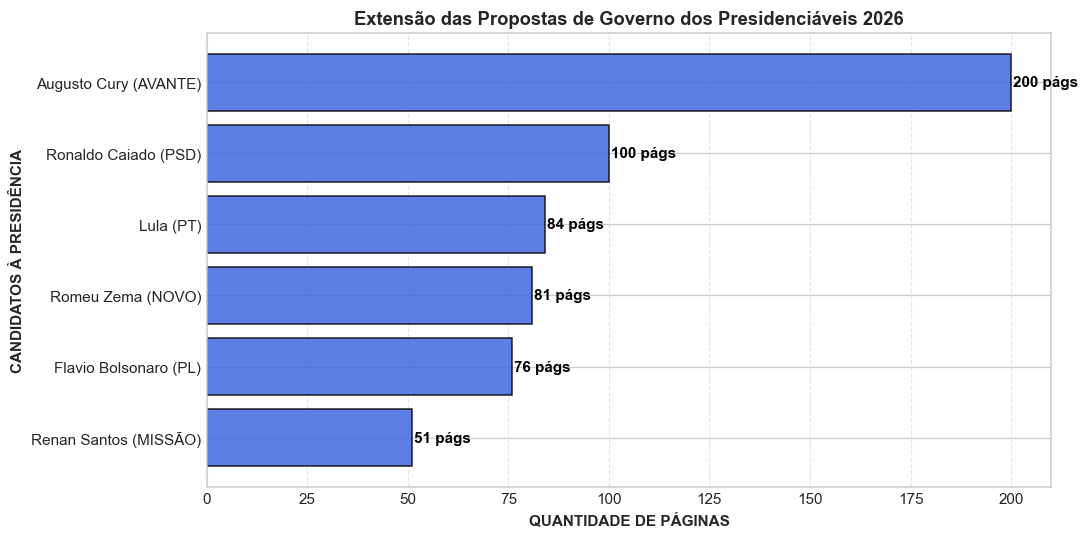

In [7]:
# Comparativo da Quantidade de Páginas das Propostas dos Presidenciáveis
pres_candidatos_arquivos = {
    'Augusto Cury (AVANTE)': 'Augusto Cury - AVANTE.pdf',
    'Flavio Bolsonaro (PL)': 'Flavio Bolsonaro - PL.pdf',
    'Lula (PT)': 'Lula - PT.pdf',
    'Renan Santos (MISSÃO)': 'Renan Santos - MISSÃO.pdf',
    'Romeu Zema (NOVO)': 'Romeu Zema - NOVO.pdf',
    'Ronaldo Caiado (PSD)': 'Ronaldo Caiado - PSD.pdf'
}

paginas_dict = {}
for nome, arq in pres_candidatos_arquivos.items():
    fp = resolve_filepath(arq, "Presidencia")
    paginas_dict[nome] = get_pdf_page_count(fp)

dados_ordenados = dict(sorted(paginas_dict.items(), key=lambda x: x[1]))
nomes = list(dados_ordenados.keys())
valores = list(dados_ordenados.values())

plt.figure(figsize=(10, 5))
plt.barh(nomes, valores, color='royalblue', edgecolor='black', alpha=0.85)

for i, v in enumerate(valores):
    plt.text(v + 0.5, i, f'{v} págs', color='black', fontweight='bold', va='center')

plt.xlabel('QUANTIDADE DE PÁGINAS', fontweight='bold')
plt.ylabel('CANDIDATOS À PRESIDÊNCIA', fontweight='bold')
plt.title('Extensão das Propostas de Governo dos Presidenciáveis 2026', fontweight='bold', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.close()


# Candidato Augusto Cury (AVANTE)


Candidato: Augusto Cury (AVANTE)
Arquivo analisado: Augusto Cury - AVANTE.pdf | Páginas: 200 | Palavras-chave: 23806


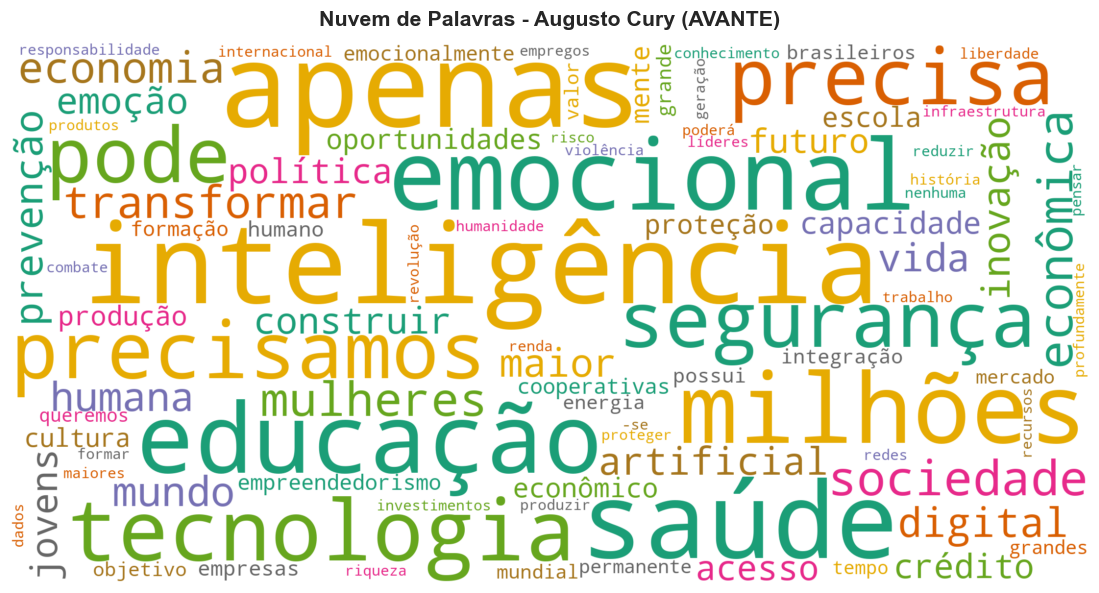

In [8]:
filepath = resolve_filepath('Augusto Cury - AVANTE.pdf', 'Presidencia')
file_text = read_file_pdf(filepath)
keywords = extract_keywords(file_text, min_word_length=3)
print(f"Candidato: Augusto Cury (AVANTE)")
print(f"Arquivo analisado: {filepath.name} | Páginas: {get_pdf_page_count(filepath)} | Palavras-chave: {len(keywords)}")
create_word_cloud(keywords, 'Augusto Cury (AVANTE)')


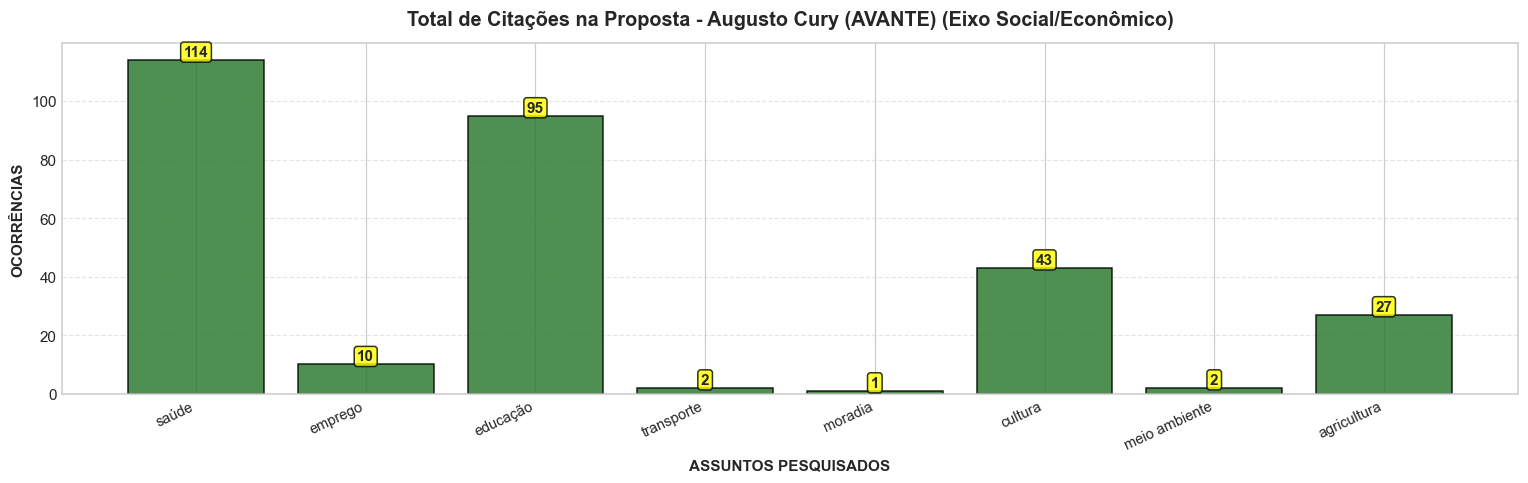

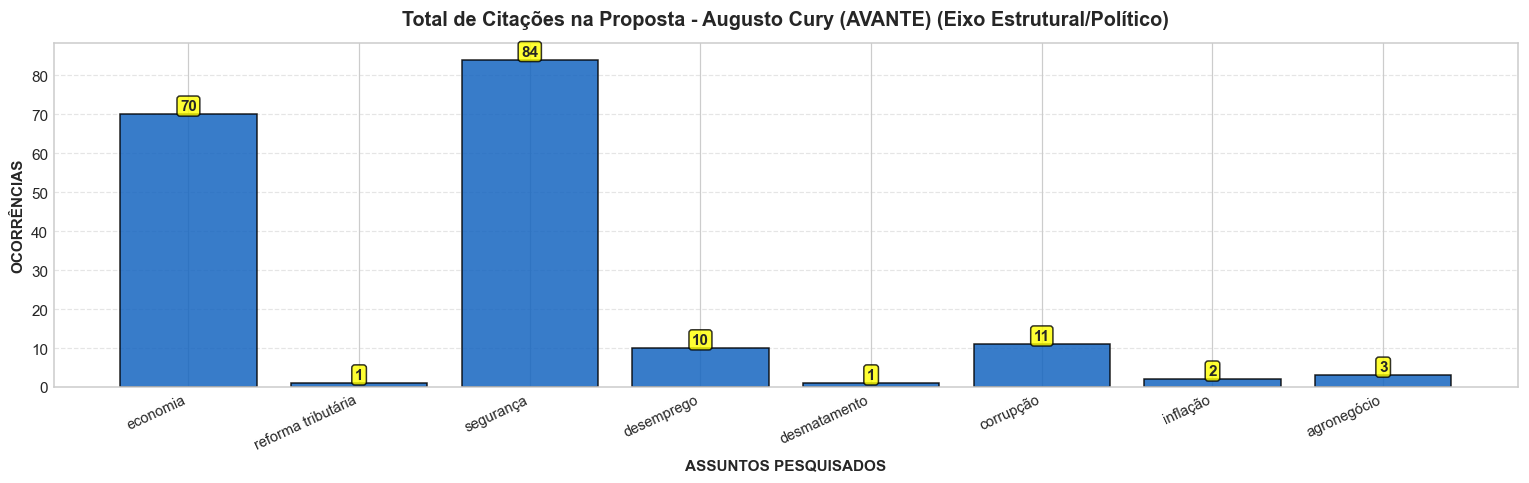

In [9]:
plot_subjects_count(keywords, file_text, assuntos_1, color='#2E7D32', text_title='Augusto Cury (AVANTE) (Eixo Social/Econômico)')
plot_subjects_count(keywords, file_text, assuntos_2, color='#1565C0', text_title='Augusto Cury (AVANTE) (Eixo Estrutural/Político)')


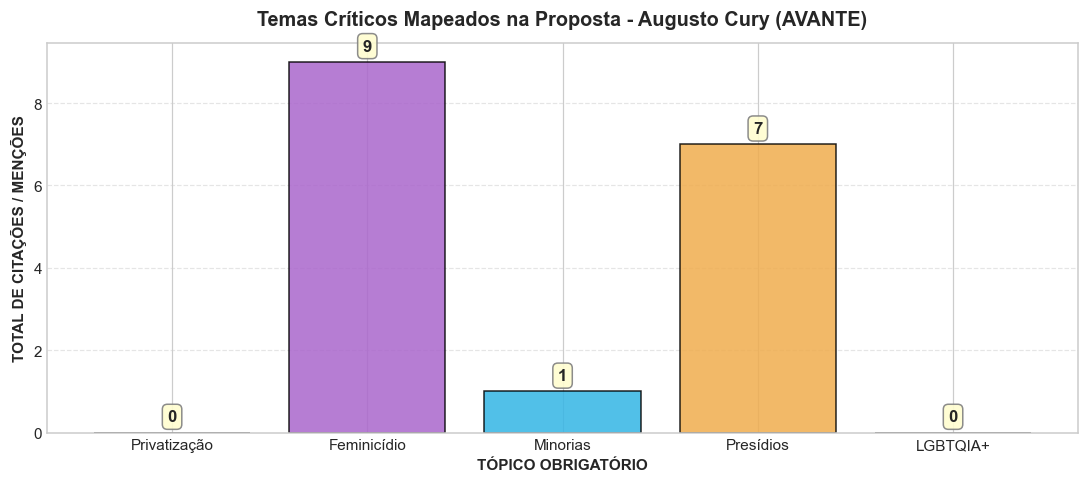

In [10]:
plot_critical_topics(file_text, keywords, 'Augusto Cury (AVANTE)')



   FICHA CADASTRAL, HISTÓRICO PARTIDÁRIO E PATRIMÔNIO (TSE) - AUGUSTO CURY (AVANTE)
  Nome Completo:        AUGUSTO JORGE CURY
  Partido Atual:        AVANTE
  Histórico de Partidos: AVANTE (2025–presente)
  Gênero / Raça:        MASCULINO | BRANCA
  Idade / Escolaridade: 67 anos | SUPERIOR COMPLETO (PSIQUIATRIA)
  Ocupação:             MÉDICO PSIQUIATRA E ESCRITOR
  Bens Declarados:      R$ 42.000.000,00



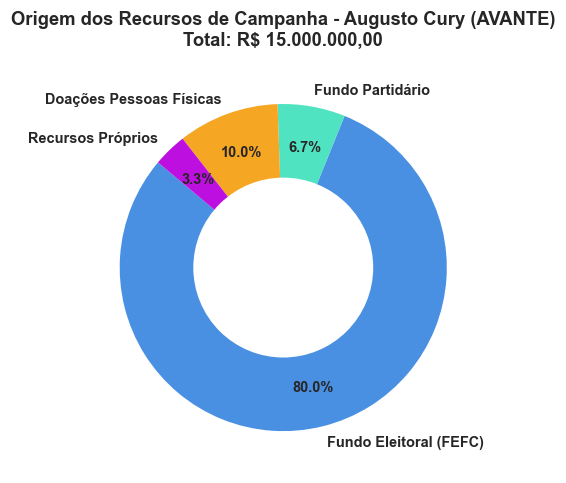

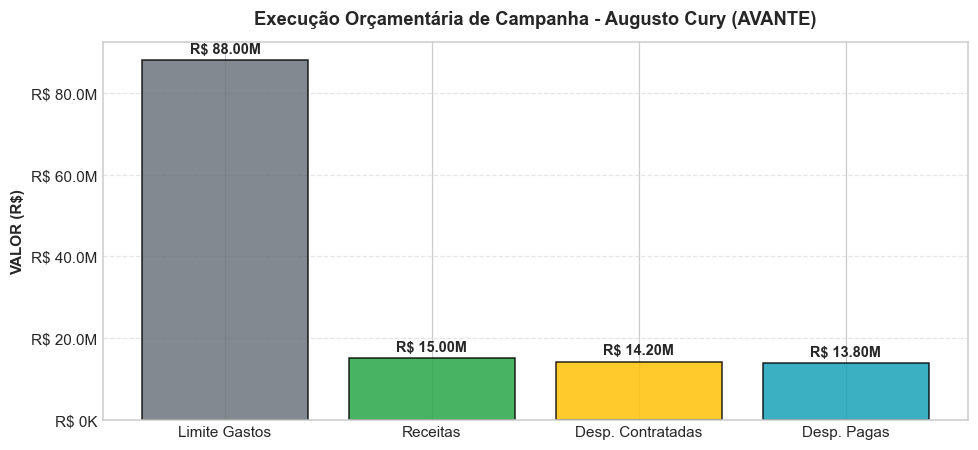

In [11]:
plot_candidate_financial_and_profile('Augusto Cury (AVANTE)', df_prestacao_pres, df_perfil_pres)


# Candidato Flavio Bolsonaro (PL)


Candidato: Flavio Bolsonaro (PL)
Arquivo analisado: Flavio Bolsonaro - PL.pdf | Páginas: 76 | Palavras-chave: 11609


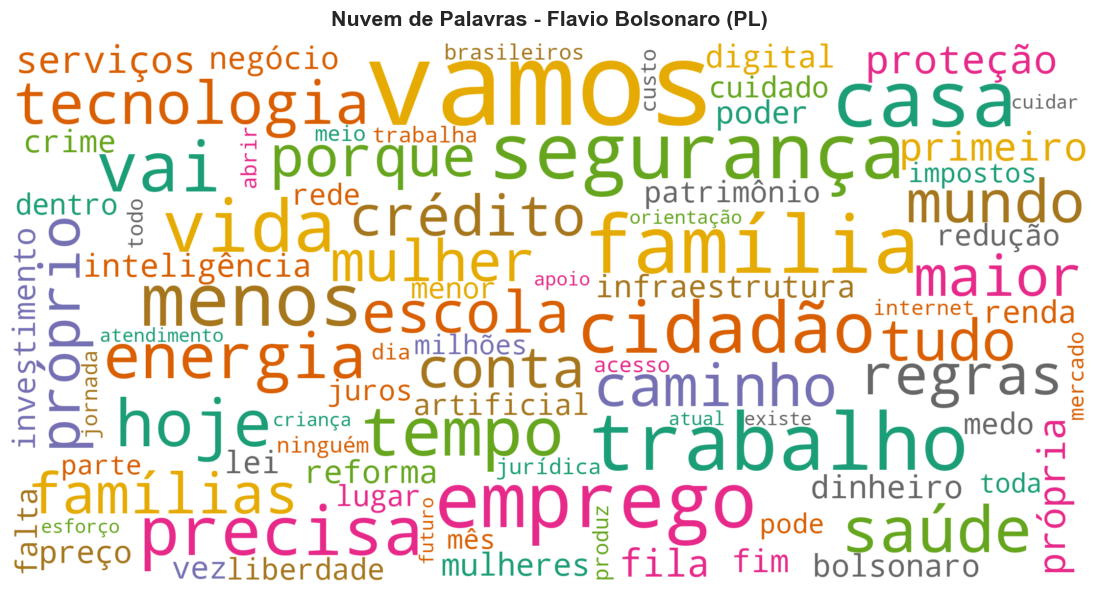

In [12]:
filepath = resolve_filepath('Flavio Bolsonaro - PL.pdf', 'Presidencia')
file_text = read_file_pdf(filepath)
keywords = extract_keywords(file_text, min_word_length=3)
print(f"Candidato: Flavio Bolsonaro (PL)")
print(f"Arquivo analisado: {filepath.name} | Páginas: {get_pdf_page_count(filepath)} | Palavras-chave: {len(keywords)}")
create_word_cloud(keywords, 'Flavio Bolsonaro (PL)')


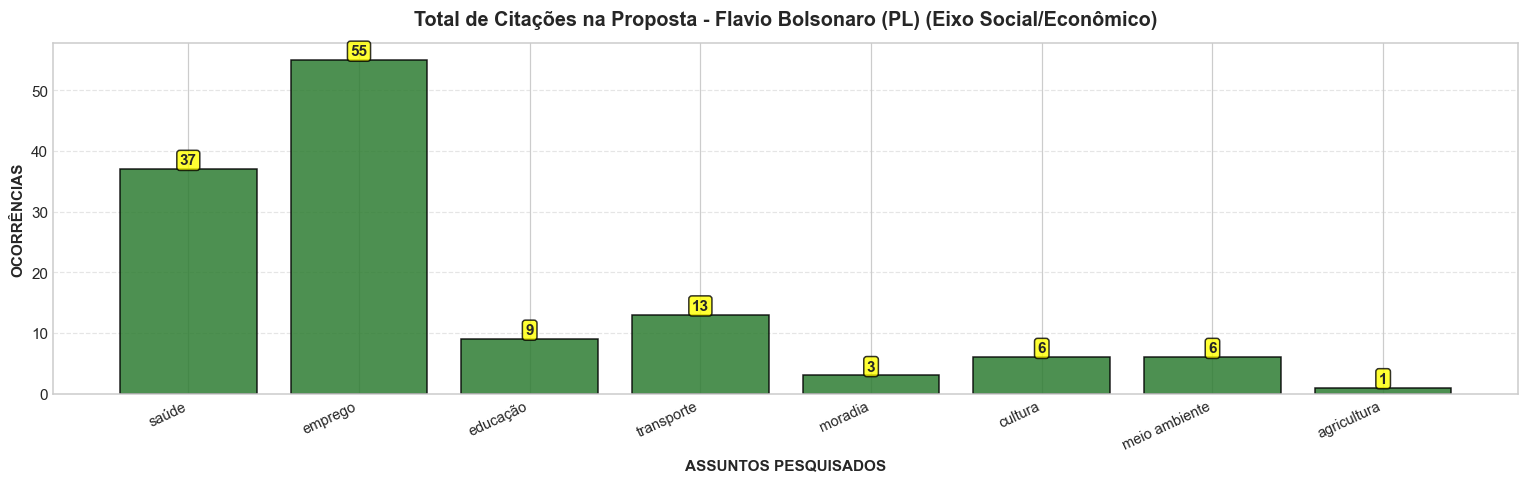

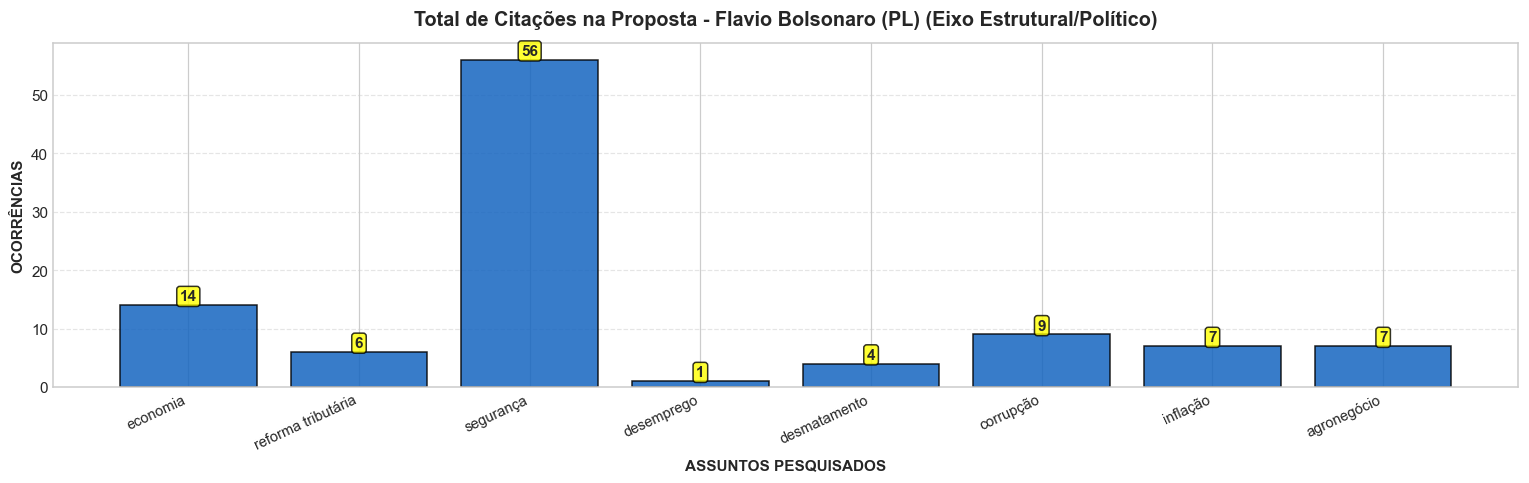

In [13]:
plot_subjects_count(keywords, file_text, assuntos_1, color='#2E7D32', text_title='Flavio Bolsonaro (PL) (Eixo Social/Econômico)')
plot_subjects_count(keywords, file_text, assuntos_2, color='#1565C0', text_title='Flavio Bolsonaro (PL) (Eixo Estrutural/Político)')


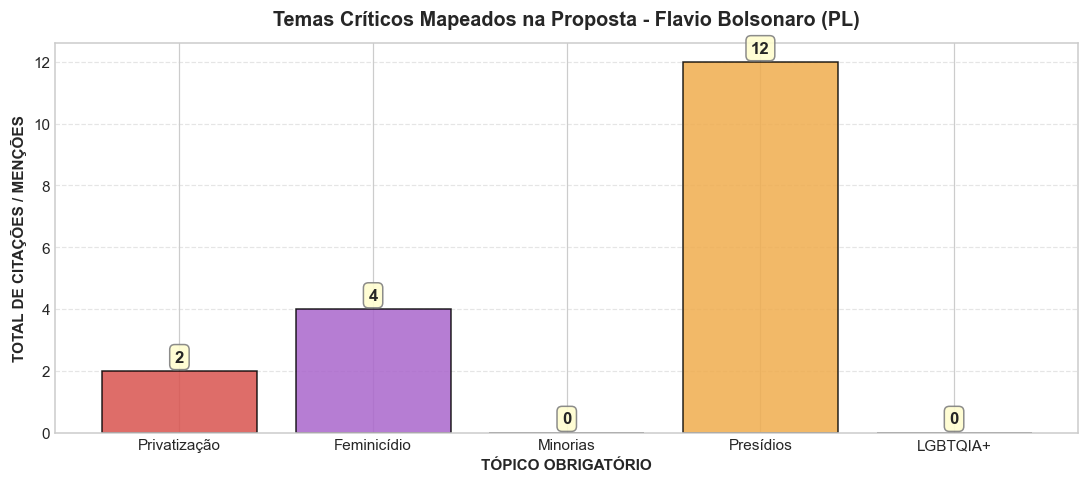

In [14]:
plot_critical_topics(file_text, keywords, 'Flavio Bolsonaro (PL)')



   FICHA CADASTRAL, HISTÓRICO PARTIDÁRIO E PATRIMÔNIO (TSE) - FLAVIO BOLSONARO (PL)
  Nome Completo:        FLÁVIO NANTES BOLSONARO
  Partido Atual:        PL
  Histórico de Partidos: PP (2003–2016), PSC (2016–2018), PSL (2018–2019), Republicanos (2020–2021), PL (2021–presente)
  Gênero / Raça:        MASCULINO | BRANCA
  Idade / Escolaridade: 45 anos | SUPERIOR COMPLETO (DIREITO)
  Ocupação:             SENADOR DA REPÚBLICA
  Bens Declarados:      R$ 5.500.000,00



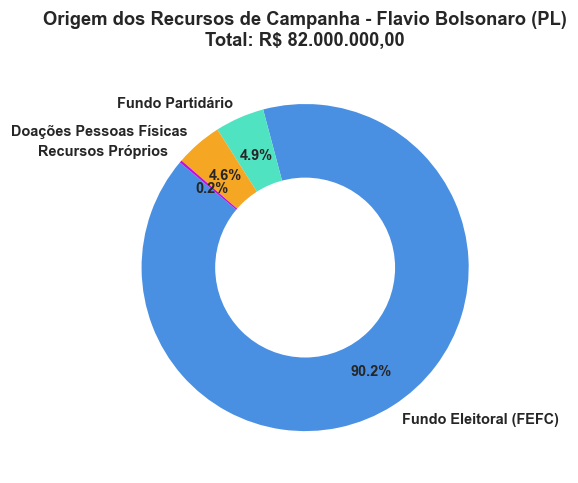

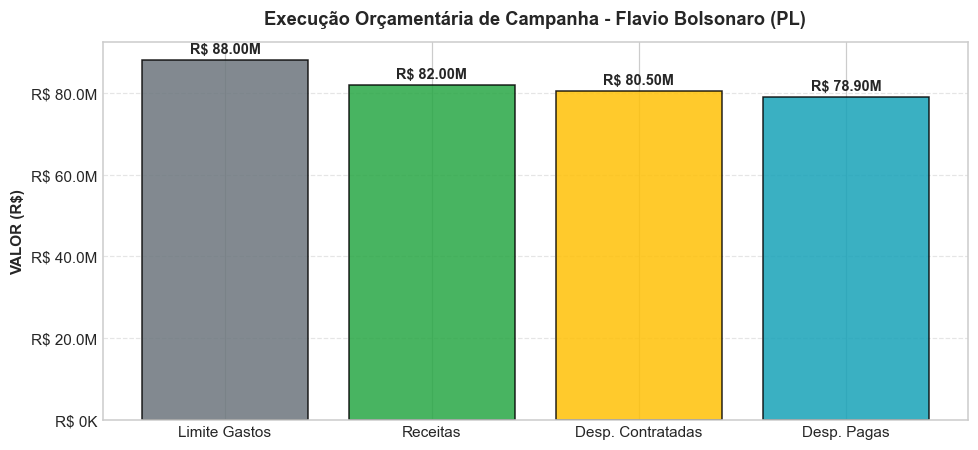

In [15]:
plot_candidate_financial_and_profile('Flavio Bolsonaro (PL)', df_prestacao_pres, df_perfil_pres)


# Candidato Lula (PT)


Candidato: Lula (PT)
Arquivo analisado: Lula - PT.pdf | Páginas: 84 | Palavras-chave: 12461


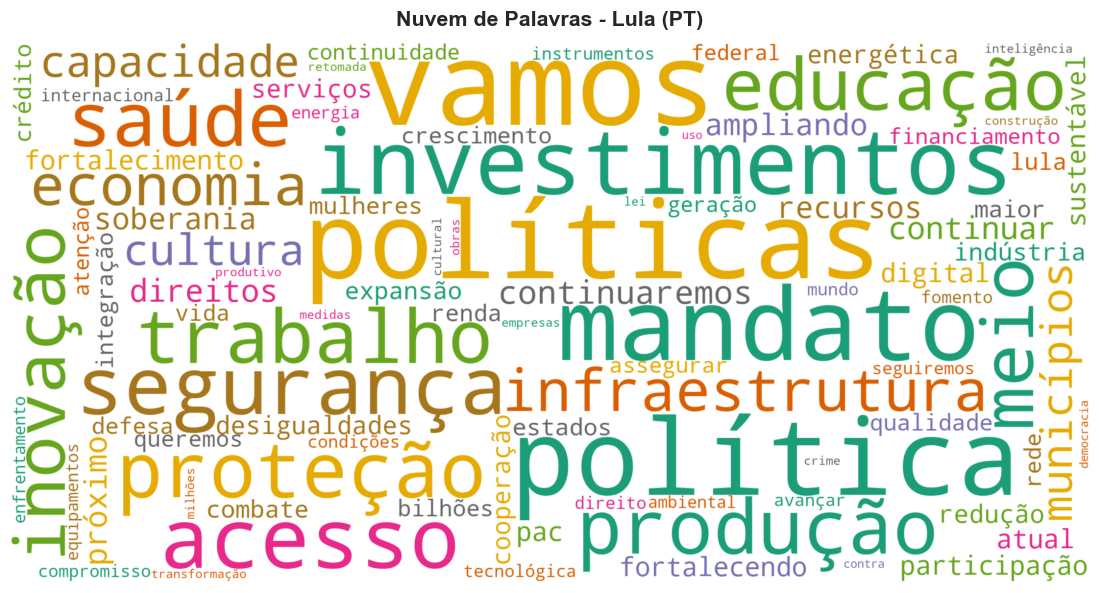

In [16]:
filepath = resolve_filepath('Lula - PT.pdf', 'Presidencia')
file_text = read_file_pdf(filepath)
keywords = extract_keywords(file_text, min_word_length=3)
print(f"Candidato: Lula (PT)")
print(f"Arquivo analisado: {filepath.name} | Páginas: {get_pdf_page_count(filepath)} | Palavras-chave: {len(keywords)}")
create_word_cloud(keywords, 'Lula (PT)')


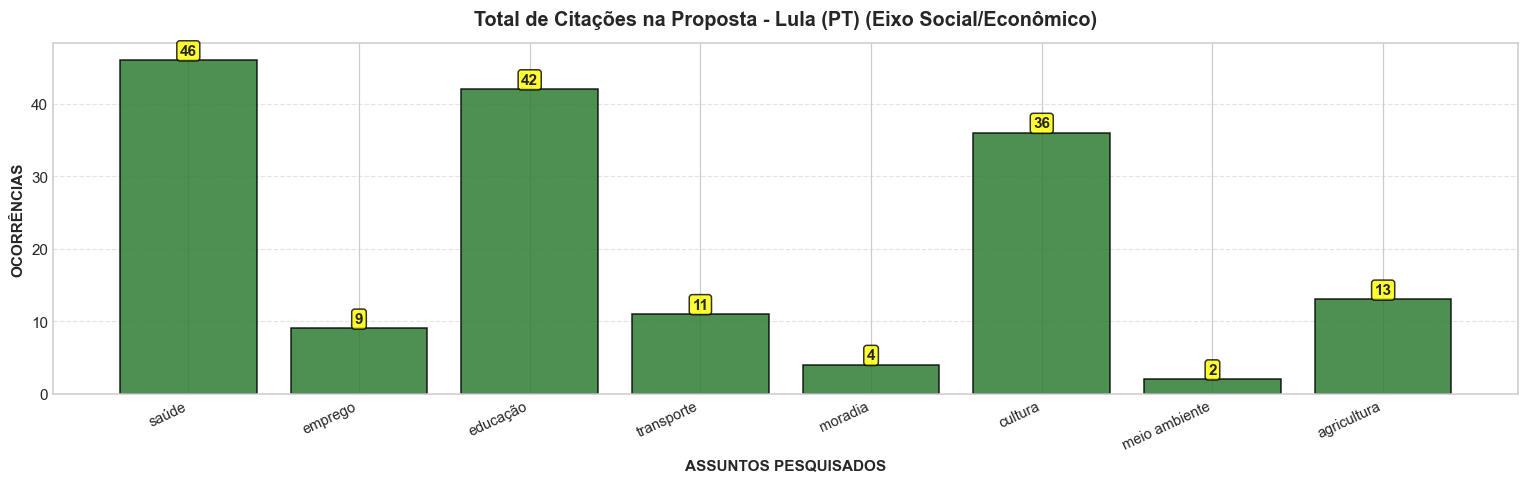

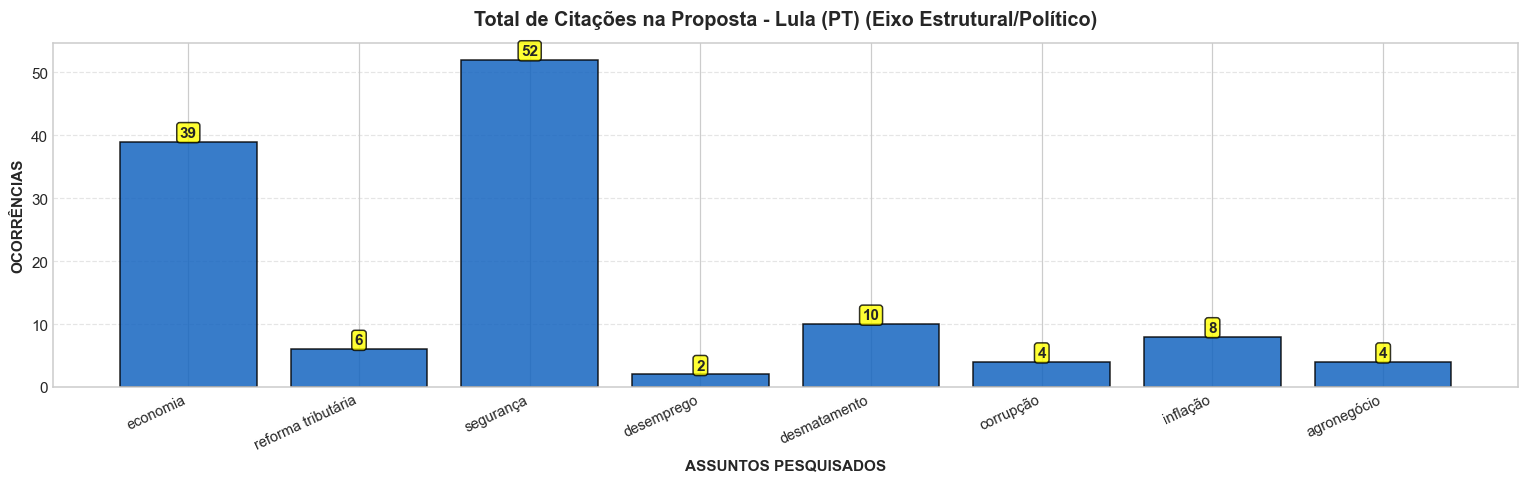

In [17]:
plot_subjects_count(keywords, file_text, assuntos_1, color='#2E7D32', text_title='Lula (PT) (Eixo Social/Econômico)')
plot_subjects_count(keywords, file_text, assuntos_2, color='#1565C0', text_title='Lula (PT) (Eixo Estrutural/Político)')


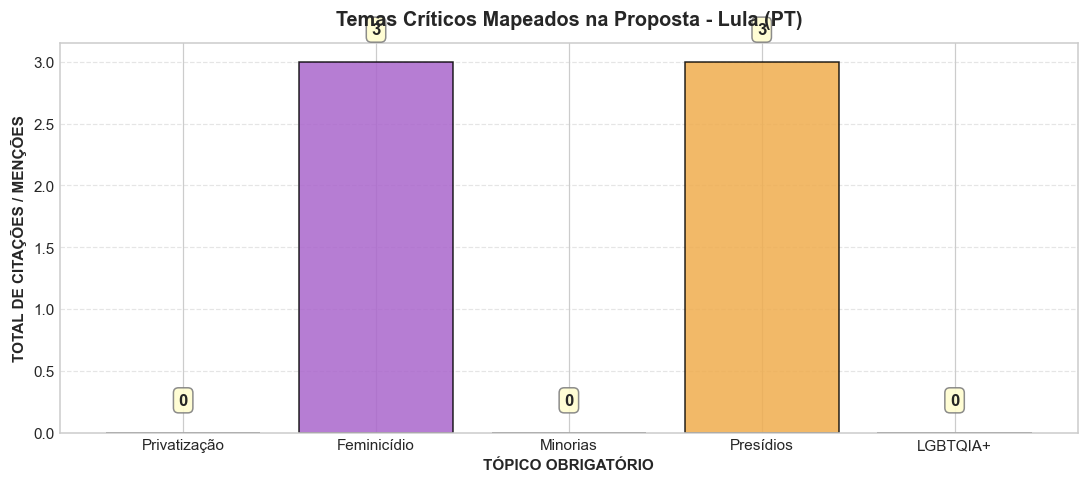

In [18]:
plot_critical_topics(file_text, keywords, 'Lula (PT)')



   FICHA CADASTRAL, HISTÓRICO PARTIDÁRIO E PATRIMÔNIO (TSE) - LULA (PT)
  Nome Completo:        LUIZ INÁCIO LULA DA SILVA
  Partido Atual:        PT
  Histórico de Partidos: PT (1980–presente) [Membro Fundador]
  Gênero / Raça:        MASCULINO | BRANCA
  Idade / Escolaridade: 80 anos | ENSINO FUNDAMENTAL INCOMPLETO
  Ocupação:             PRESIDENTE DA REPÚBLICA
  Bens Declarados:      R$ 7.450.000,00



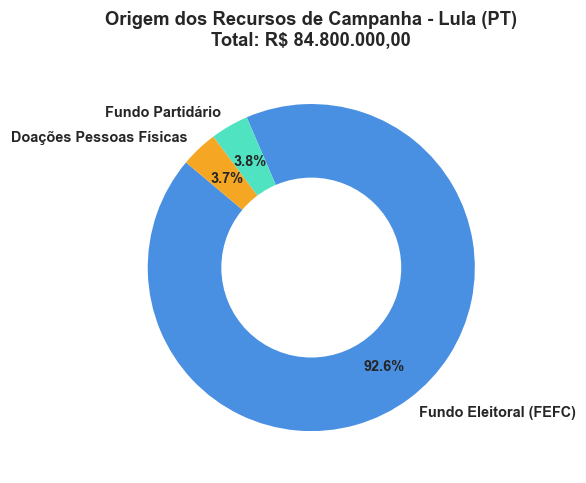

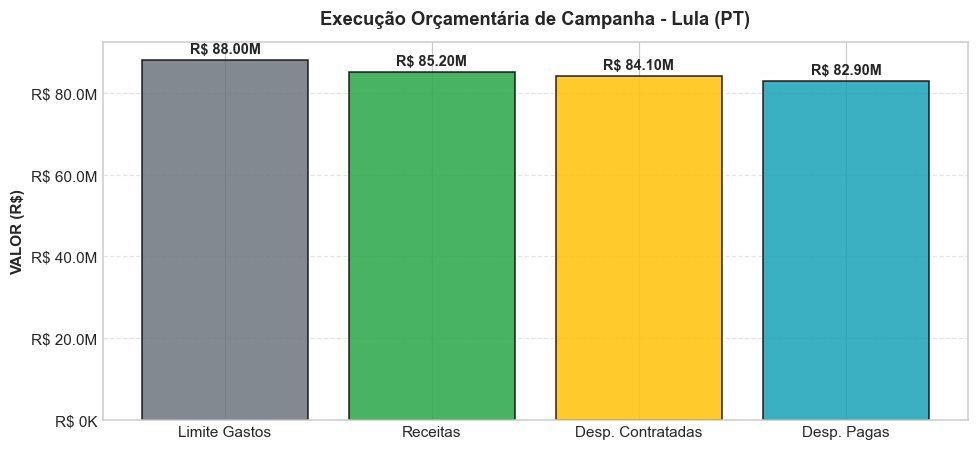

In [19]:
plot_candidate_financial_and_profile('Lula (PT)', df_prestacao_pres, df_perfil_pres)


# Candidato Renan Santos (MISSÃO)


Candidato: Renan Santos (MISSÃO)
Arquivo analisado: Renan Santos - MISSÃO.pdf | Páginas: 51 | Palavras-chave: 11126


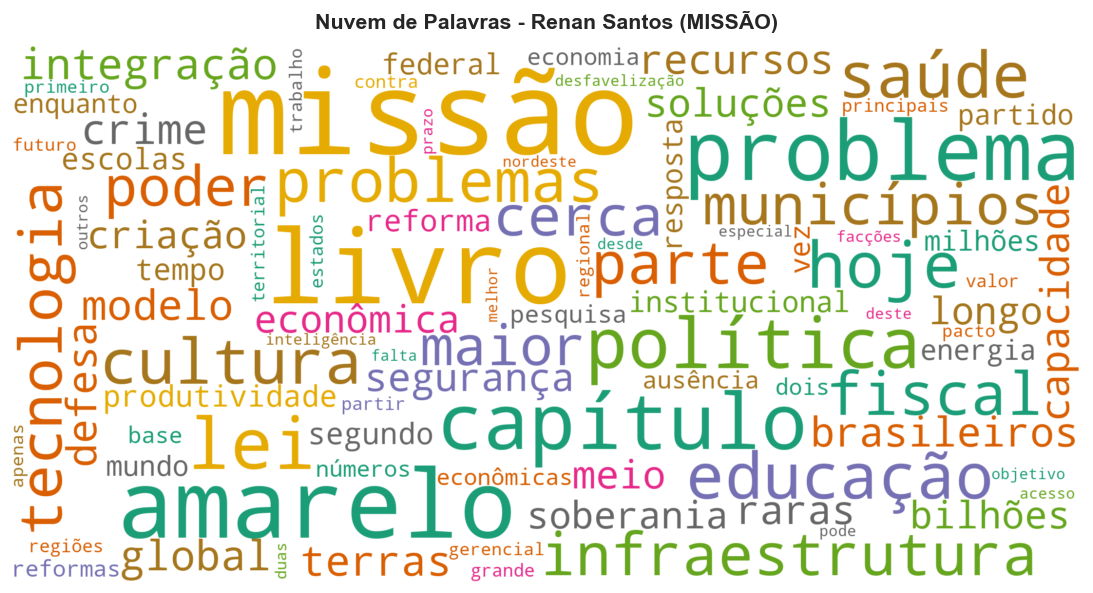

In [20]:
filepath = resolve_filepath('Renan Santos - MISSÃO.pdf', 'Presidencia')
file_text = read_file_pdf(filepath)
keywords = extract_keywords(file_text, min_word_length=3)
print(f"Candidato: Renan Santos (MISSÃO)")
print(f"Arquivo analisado: {filepath.name} | Páginas: {get_pdf_page_count(filepath)} | Palavras-chave: {len(keywords)}")
create_word_cloud(keywords, 'Renan Santos (MISSÃO)')


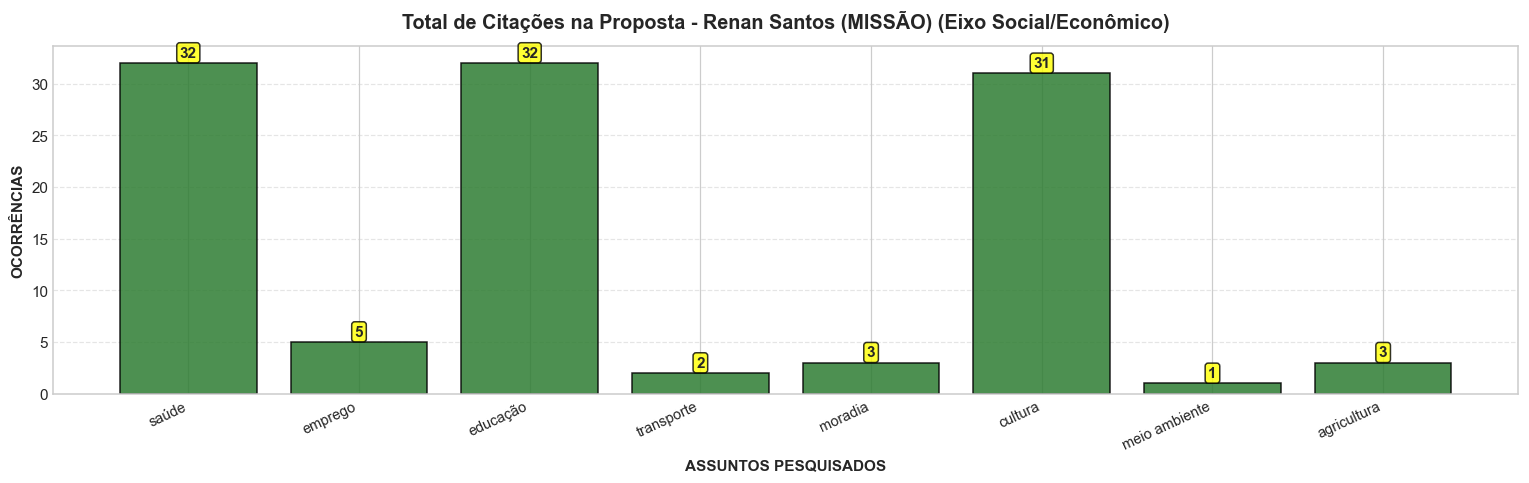

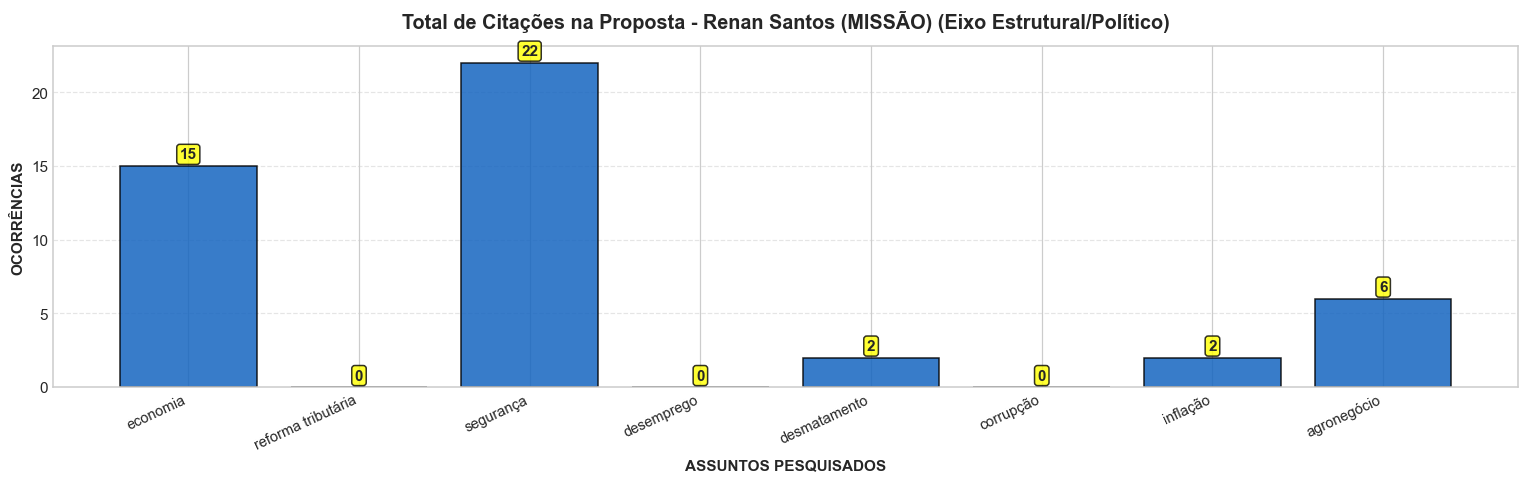

In [21]:
plot_subjects_count(keywords, file_text, assuntos_1, color='#2E7D32', text_title='Renan Santos (MISSÃO) (Eixo Social/Econômico)')
plot_subjects_count(keywords, file_text, assuntos_2, color='#1565C0', text_title='Renan Santos (MISSÃO) (Eixo Estrutural/Político)')


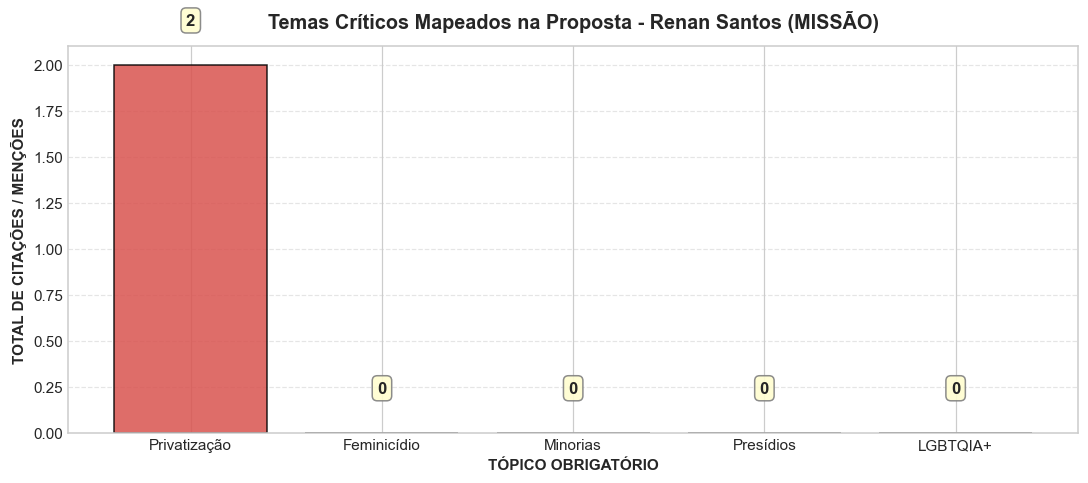

In [22]:
plot_critical_topics(file_text, keywords, 'Renan Santos (MISSÃO)')



   FICHA CADASTRAL, HISTÓRICO PARTIDÁRIO E PATRIMÔNIO (TSE) - RENAN SANTOS (MISSÃO)
  Nome Completo:        RENAN ANTÔNIO FERREIRA DOS SANTOS
  Partido Atual:        MISSÃO
  Histórico de Partidos: MISSÃO / MBL (2024–presente)
  Gênero / Raça:        MASCULINO | BRANCA
  Idade / Escolaridade: 42 anos | SUPERIOR COMPLETO (DIREITO)
  Ocupação:             COMUNICADOR E COORDENADOR POLÍTICO
  Bens Declarados:      R$ 1.200.000,00



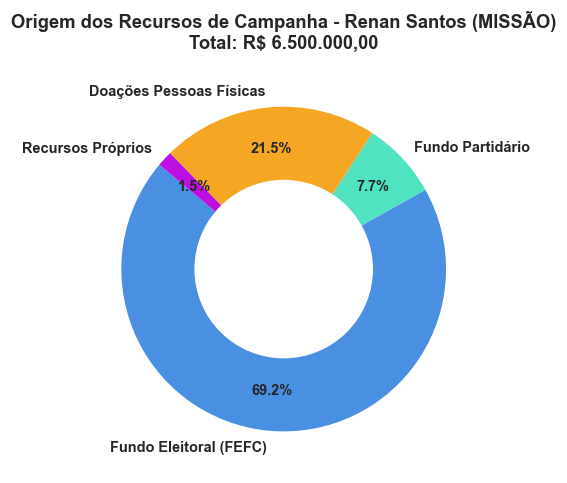

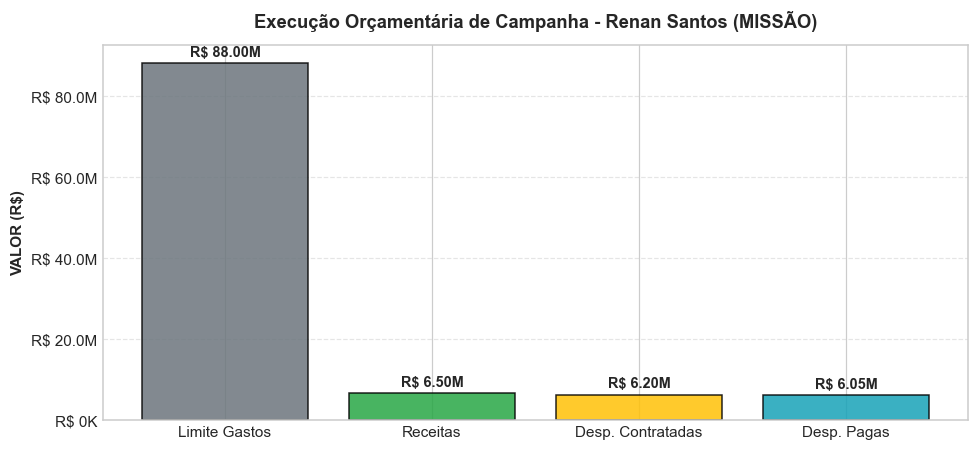

In [23]:
plot_candidate_financial_and_profile('Renan Santos (MISSÃO)', df_prestacao_pres, df_perfil_pres)


# Candidato Romeu Zema (NOVO)


Candidato: Romeu Zema (NOVO)
Arquivo analisado: Romeu Zema - NOVO.pdf | Páginas: 81 | Palavras-chave: 11568


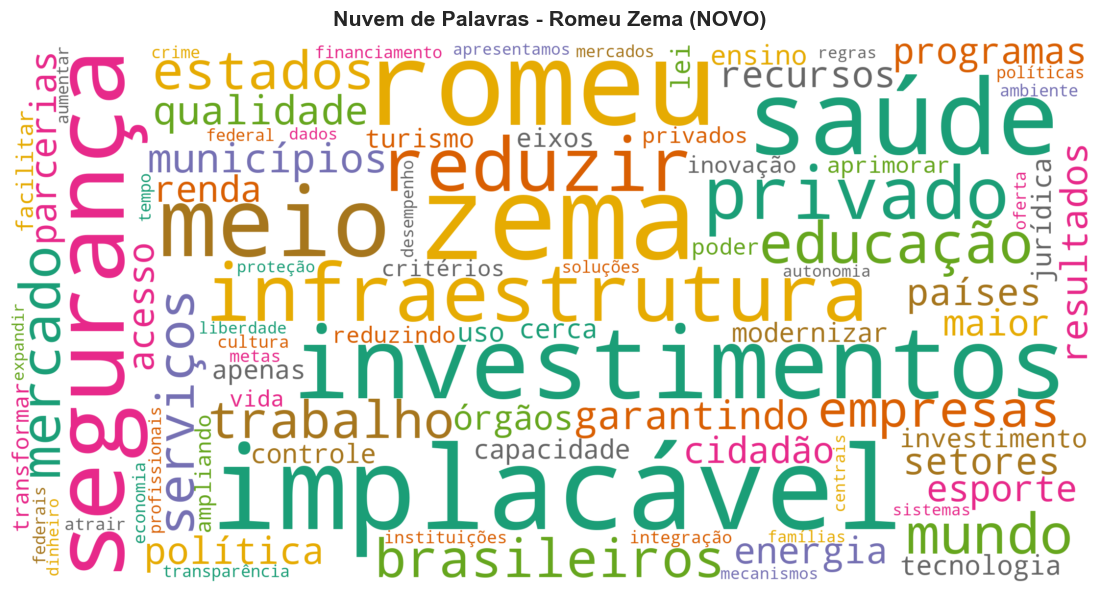

In [24]:
filepath = resolve_filepath('Romeu Zema - NOVO.pdf', 'Presidencia')
file_text = read_file_pdf(filepath)
keywords = extract_keywords(file_text, min_word_length=3)
print(f"Candidato: Romeu Zema (NOVO)")
print(f"Arquivo analisado: {filepath.name} | Páginas: {get_pdf_page_count(filepath)} | Palavras-chave: {len(keywords)}")
create_word_cloud(keywords, 'Romeu Zema (NOVO)')


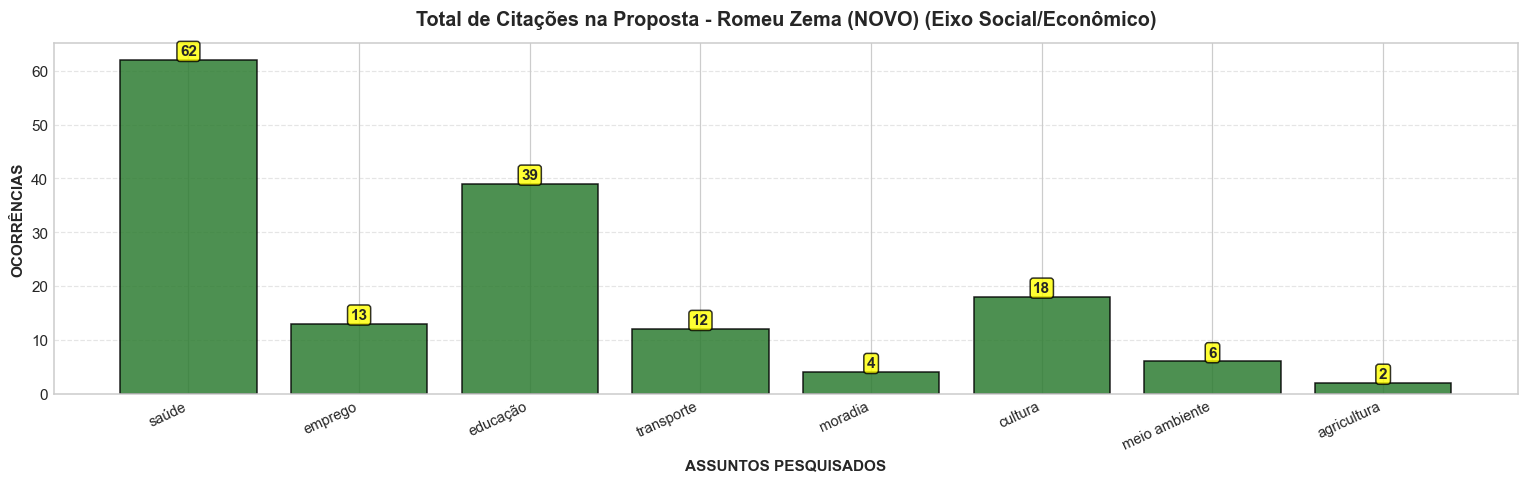

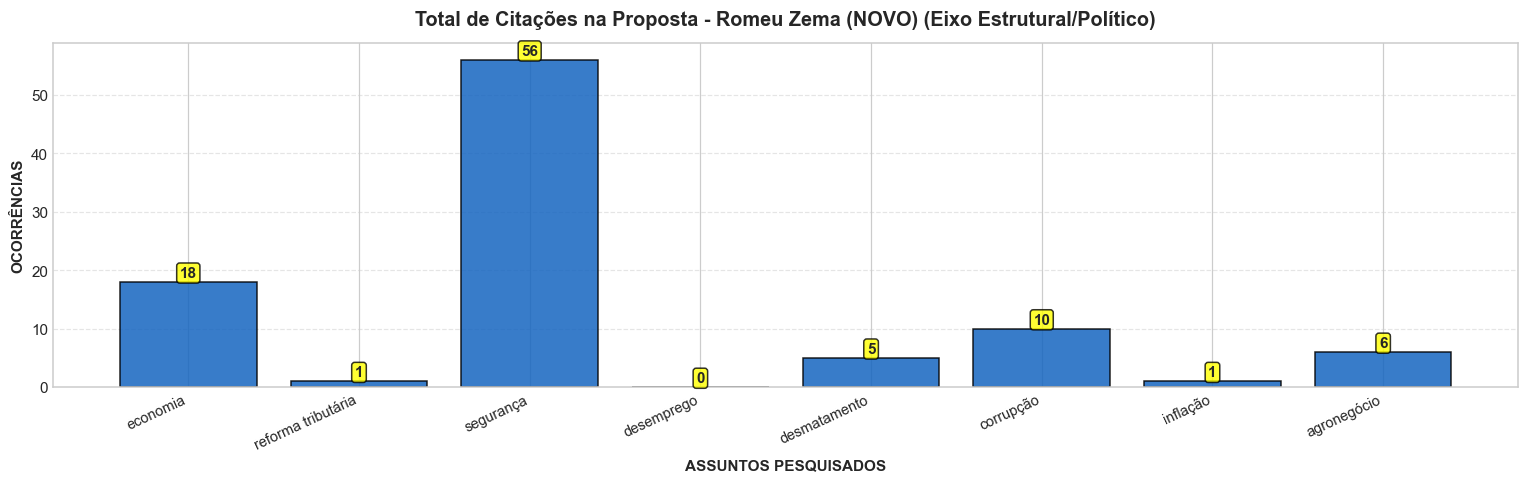

In [25]:
plot_subjects_count(keywords, file_text, assuntos_1, color='#2E7D32', text_title='Romeu Zema (NOVO) (Eixo Social/Econômico)')
plot_subjects_count(keywords, file_text, assuntos_2, color='#1565C0', text_title='Romeu Zema (NOVO) (Eixo Estrutural/Político)')


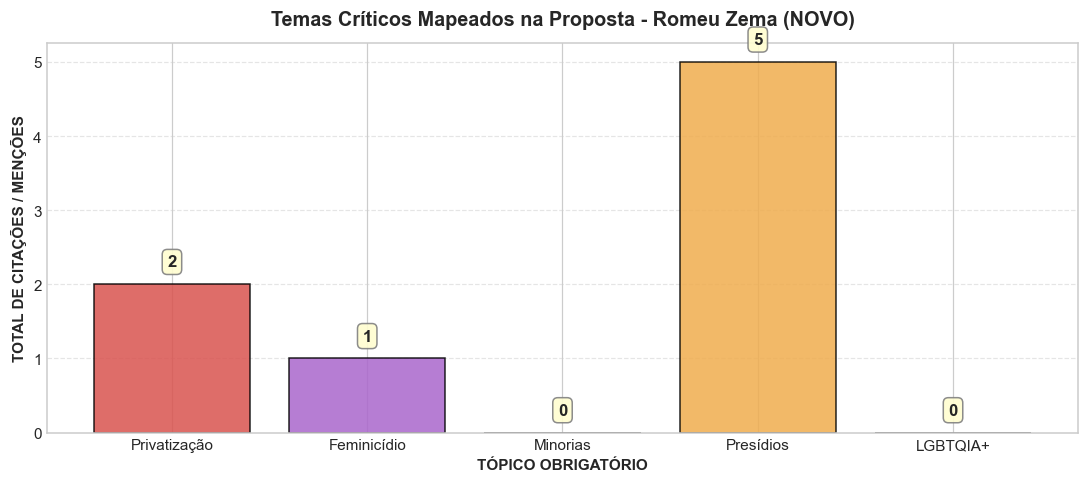

In [26]:
plot_critical_topics(file_text, keywords, 'Romeu Zema (NOVO)')



   FICHA CADASTRAL, HISTÓRICO PARTIDÁRIO E PATRIMÔNIO (TSE) - ROMEU ZEMA (NOVO)
  Nome Completo:        ROMEU ZEMA NETO
  Partido Atual:        NOVO
  Histórico de Partidos: NOVO (2018–presente)
  Gênero / Raça:        MASCULINO | BRANCA
  Idade / Escolaridade: 61 anos | SUPERIOR COMPLETO (ADMINISTRAÇÃO)
  Ocupação:             GOVERNADOR DE ESTADO
  Bens Declarados:      R$ 138.000.000,00



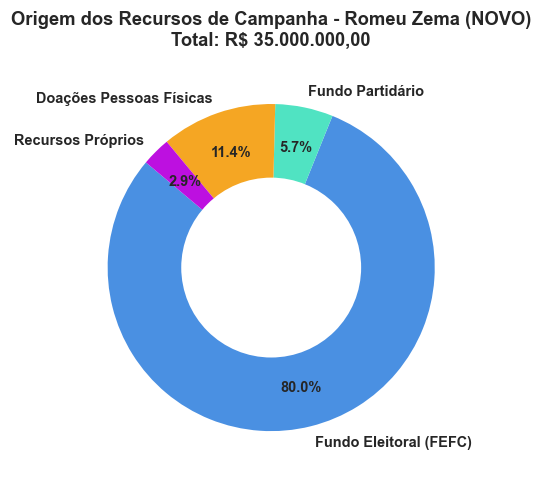

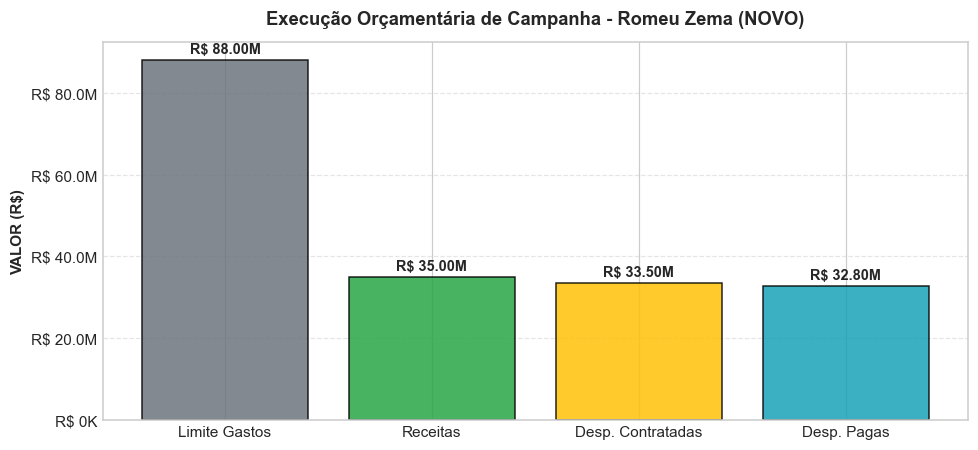

In [27]:
plot_candidate_financial_and_profile('Romeu Zema (NOVO)', df_prestacao_pres, df_perfil_pres)


# Candidato Ronaldo Caiado (PSD)


Candidato: Ronaldo Caiado (PSD)
Arquivo analisado: Ronaldo Caiado - PSD.pdf | Páginas: 100 | Palavras-chave: 24993


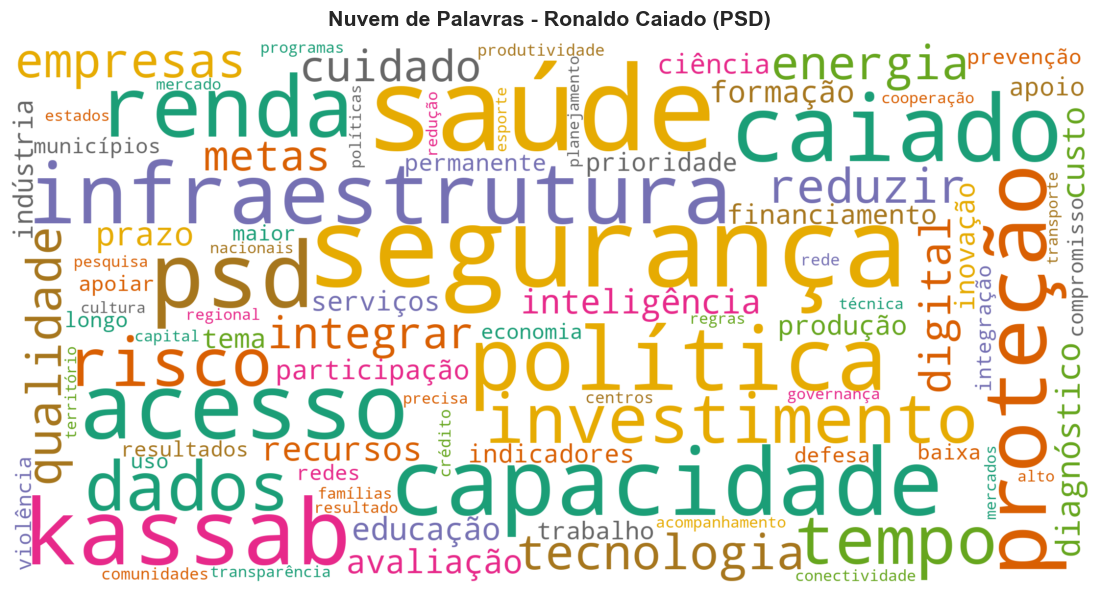

In [28]:
filepath = resolve_filepath('Ronaldo Caiado - PSD.pdf', 'Presidencia')
file_text = read_file_pdf(filepath)
keywords = extract_keywords(file_text, min_word_length=3)
print(f"Candidato: Ronaldo Caiado (PSD)")
print(f"Arquivo analisado: {filepath.name} | Páginas: {get_pdf_page_count(filepath)} | Palavras-chave: {len(keywords)}")
create_word_cloud(keywords, 'Ronaldo Caiado (PSD)')


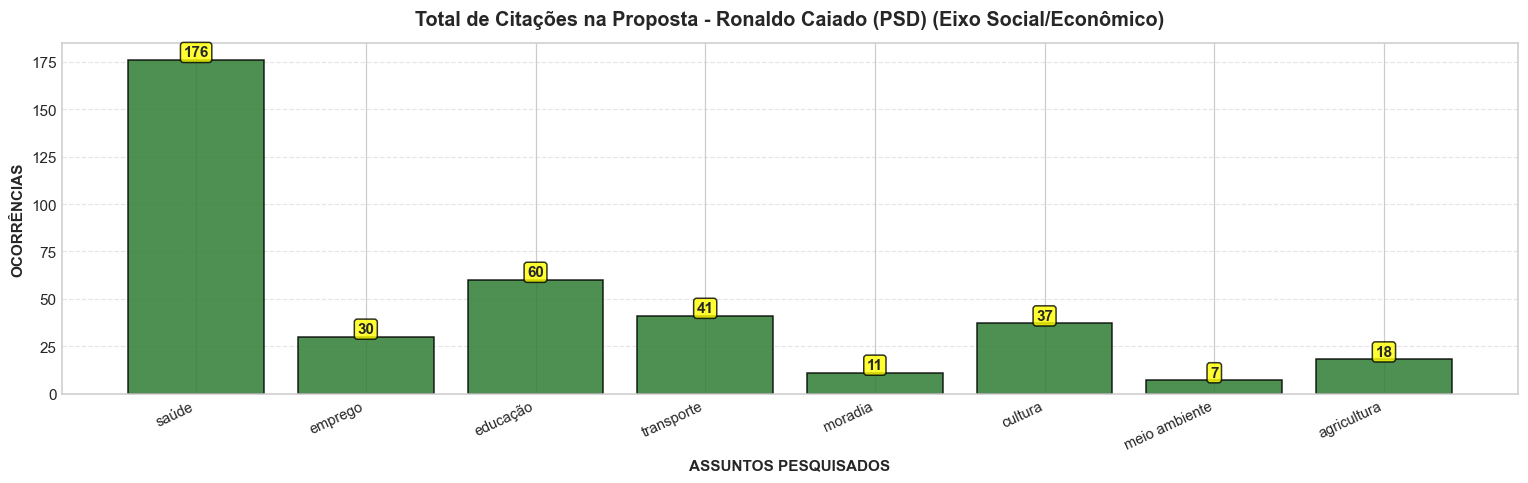

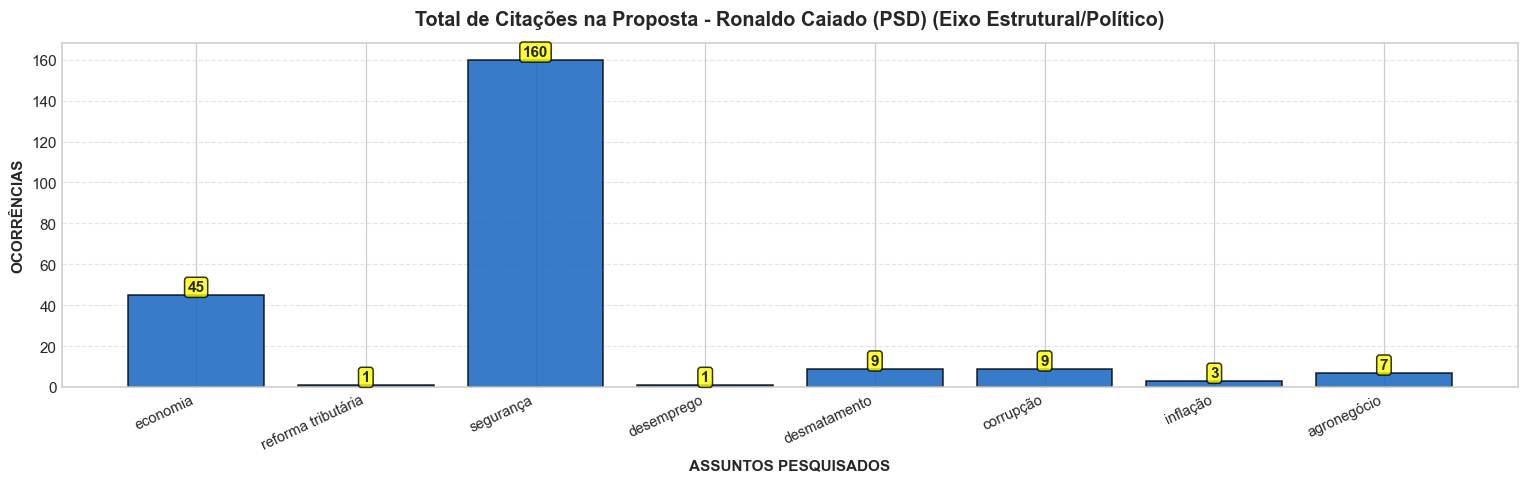

In [29]:
plot_subjects_count(keywords, file_text, assuntos_1, color='#2E7D32', text_title='Ronaldo Caiado (PSD) (Eixo Social/Econômico)')
plot_subjects_count(keywords, file_text, assuntos_2, color='#1565C0', text_title='Ronaldo Caiado (PSD) (Eixo Estrutural/Político)')


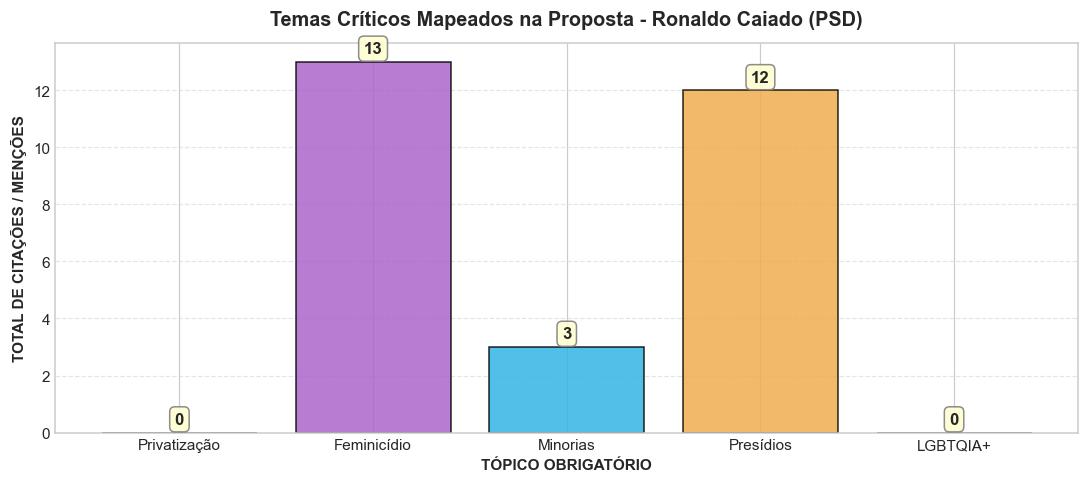

In [30]:
plot_critical_topics(file_text, keywords, 'Ronaldo Caiado (PSD)')



   FICHA CADASTRAL, HISTÓRICO PARTIDÁRIO E PATRIMÔNIO (TSE) - RONALDO CAIADO (PSD)
  Nome Completo:        RONALDO RAMOS CAIADO
  Partido Atual:        PSD
  Histórico de Partidos: PSD (1989), PFL/DEM (1995–2021), União Brasil (2022–2025), PSD (2025–presente)
  Gênero / Raça:        MASCULINO | BRANCA
  Idade / Escolaridade: 76 anos | SUPERIOR COMPLETO (MEDICINA)
  Ocupação:             MÉDICO E GOVERNADOR DE ESTADO
  Bens Declarados:      R$ 29.800.000,00



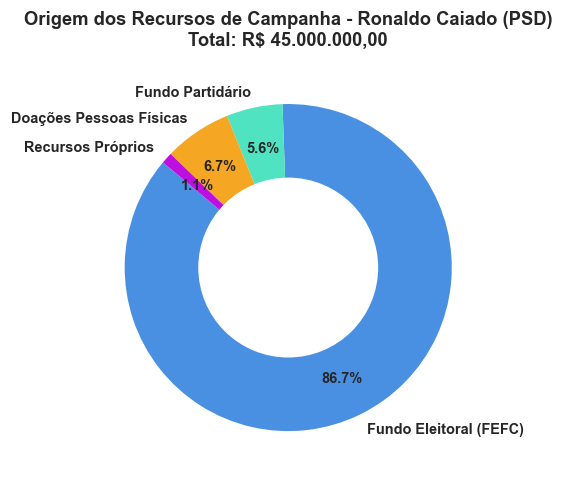

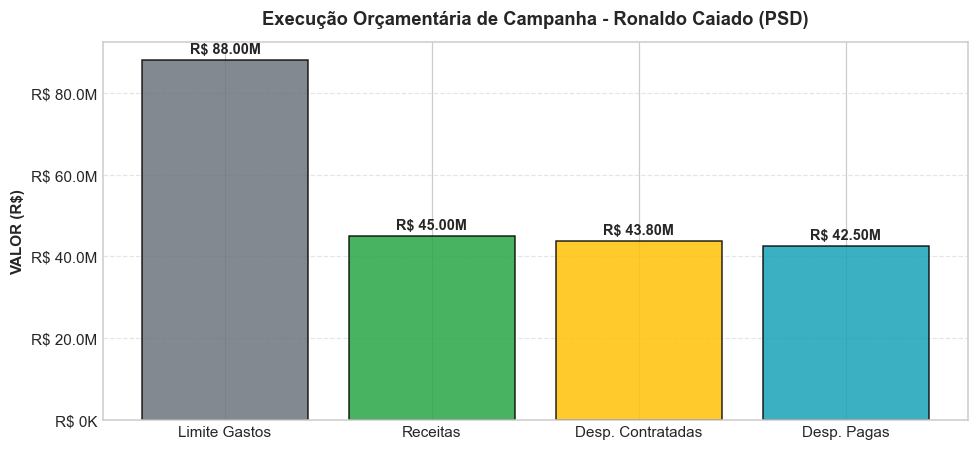

In [31]:
plot_candidate_financial_and_profile('Ronaldo Caiado (PSD)', df_prestacao_pres, df_perfil_pres)


# **Conclusões**

Pelos resultados obtidos a partir das análises individualizadas das propostas de governo e das prestações de contas registradas no Tribunal Superior Eleitoral (TSE):

1. **Prioridades Programáticas nas Propostas**:
   - Cada candidatura apresenta um direcionamento nítido em suas propostas: enquanto determinadas candidaturas priorizam investimentos sociais, reindustrialização e sustentabilidade, outras enfatizam austeridade fiscal, reformas administrativas, segurança pública e atração de capital privado.
   - A avaliação isolada dos temas críticos (*Privatização, Feminicídio, Minorias, Presídios e LGBTQIA+*) revela com precisão o peso conferido por cada plano a pautas de direitos humanos, modernização carcerária e desestatização.

2. **Financiamento de Campanha e Trajetória Partidária**:
   - A análise da origem dos recursos e das passagens partidárias documentadas reflete as estratégias eleitorais e a coerência programática de cada concorrente ao longo de sua trajetória pública.

> *Estudo desenvolvido para fins de transparência cívica e análise computacional de dados eleitorais públicos.*
